<a href="https://colab.research.google.com/github/juanfran18gc-code/jfMIAAD/blob/08-Semana/Practica21_261554.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autor: Juan Francisco Gámez Cortés.
Matricula: 261554

Última Modificación: 04 de octubre de 2025

# Práctica #21: Ejercicios con EDA 2
# Objetivo:
Realizar el Análisis Exploratorio de Datos del conjunto Haberman's Survival

## Descripción del conjunto de datos:


Utiliza el conjunto de datos "Haberman's Survival" disponible en el siguiente 'https://archive.ics.uci.edu/ml/machine-learning-databases/haberman/haberman.data"'. Este conjunto contiene datos de pacientes con cáncer de mama, incluyendo edad, año de operación, número de ganglios axilares y estado de supervivencia (categórico). El conjunto de datos tiene valores faltantes.

In [1]:
#Montar google drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [48]:
# Importar bibliotecas a utilizar en el análisis
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Instrucciones para los estudiantes:

1. Descargar el archivo "Haberman's Survival" desde el enlace proporcionado.

In [67]:
# Cargar el dataset "Haberman's Survival"
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/haberman/haberman.data"
column_names = ['edad', 'año_operacion', 'nodos_positivos', 'estatus']
df = pd.read_csv(url, header=None, names=column_names)

#Observar las columnas y datos del dataframe
print(df.head())
print(df.tail())
print('\n',df.dtypes)


   edad  año_operacion  nodos_positivos  estatus
0    30             64                1        1
1    30             62                3        1
2    30             65                0        1
3    31             59                2        1
4    31             65                4        1
     edad  año_operacion  nodos_positivos  estatus
301    75             62                1        1
302    76             67                0        1
303    77             65                3        1
304    78             65                1        2
305    83             58                2        2

 edad               int64
año_operacion      int64
nodos_positivos    int64
estatus            int64
dtype: object


## 2.  Realizar un EDA completo, incluyendo:

* Descripción de los datos (medias, medianas, desviaciones estándar, etc.).

In [68]:
# Estadísticos básicos

#Convertir Statua a category
df['estatus'] = df['estatus'].astype('category')

# Obtener columnas numéricas

col_numericas = df.select_dtypes(include=['number']).columns.tolist()

print("Tipos de dato por columna:\n")
print(df.info())
print("Estadístos básicos:\n",df[col_numericas].describe())

moda = df.mode().iloc[0]  # .iloc[0] toma solo el primer valor en caso de múltiples modas
varianza = df[col_numericas].var() #solo variables numericas

# Mostrar la moda de cada columna
print("\nModa de cada columna:")
print(moda)
print('\n')

# Mostrar la varianza de cada columna
print("Varianza de cada columna:")
print(varianza)
print('\n')

# Verificar valores faltantes
print("Valores faltantes:\n",df.isnull().sum())


Tipos de dato por columna:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 4 columns):
 #   Column           Non-Null Count  Dtype   
---  ------           --------------  -----   
 0   edad             306 non-null    int64   
 1   año_operacion    306 non-null    int64   
 2   nodos_positivos  306 non-null    int64   
 3   estatus          306 non-null    category
dtypes: category(1), int64(3)
memory usage: 7.7 KB
None
Estadístos básicos:
              edad  año_operacion  nodos_positivos
count  306.000000     306.000000       306.000000
mean    52.457516      62.852941         4.026144
std     10.803452       3.249405         7.189654
min     30.000000      58.000000         0.000000
25%     44.000000      60.000000         0.000000
50%     52.000000      63.000000         1.000000
75%     60.750000      65.750000         4.000000
max     83.000000      69.000000        52.000000

Moda de cada columna:
edad               52
año_operacion 

### Histogramas para las columnas numéricas.

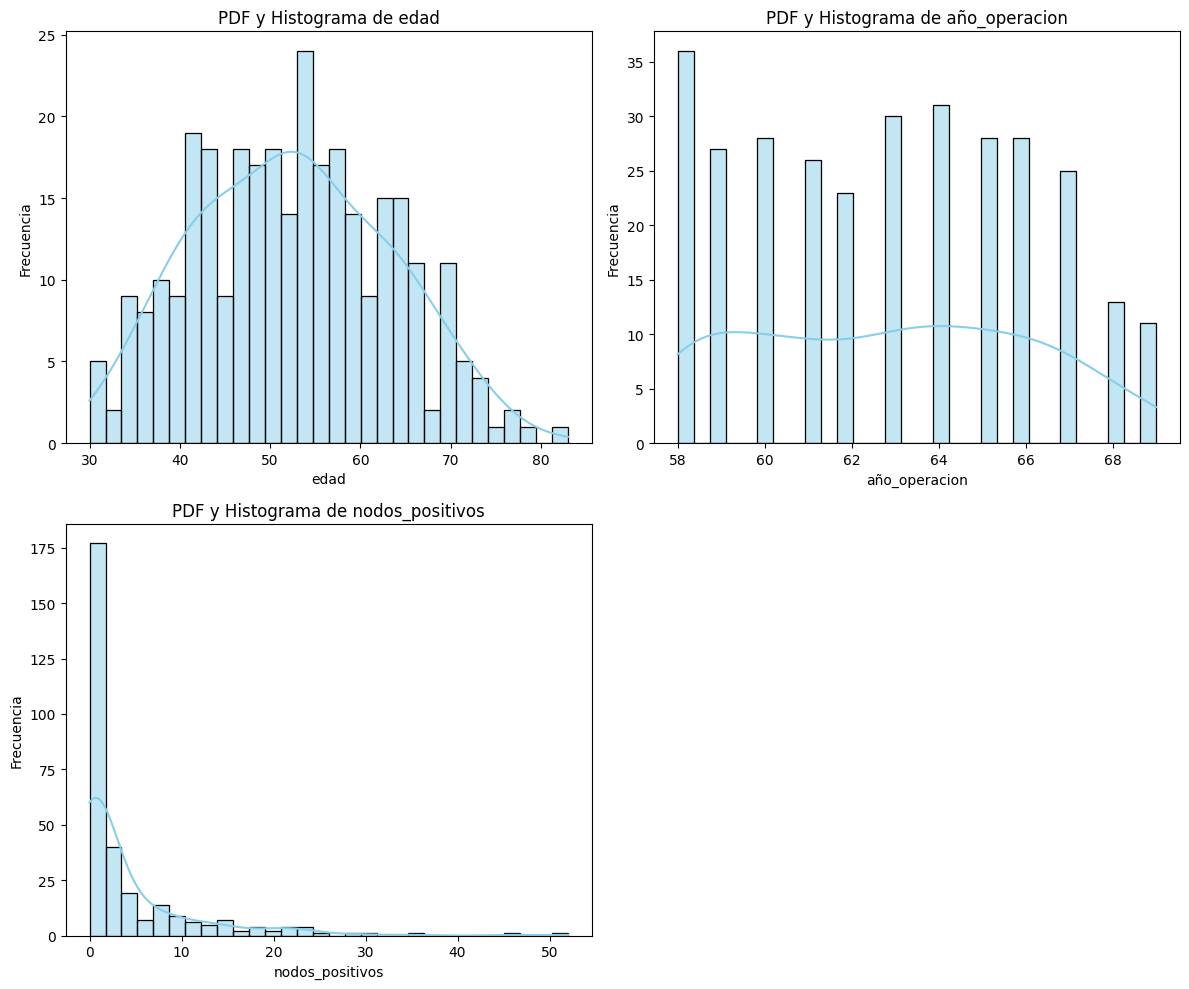

In [69]:
# Crear los gráficos de PDF e Histograma

plt.figure(figsize=(12, 10))
for i, col in enumerate(col_numericas, 1):
    plt.subplot(2, 2, i)  # Ajustar la cantidad de subgráficos según el número de columnas
    sns.histplot(df[col], kde=True, bins=30, color='skyblue')
    plt.title(f'PDF y Histograma de {col}', fontsize=12)
    plt.xlabel(col, fontsize=10)
    plt.ylabel('Frecuencia', fontsize=10)

plt.tight_layout()
plt.show()

### Gráficas de barras para la columna categórica `status` (supervivencia).

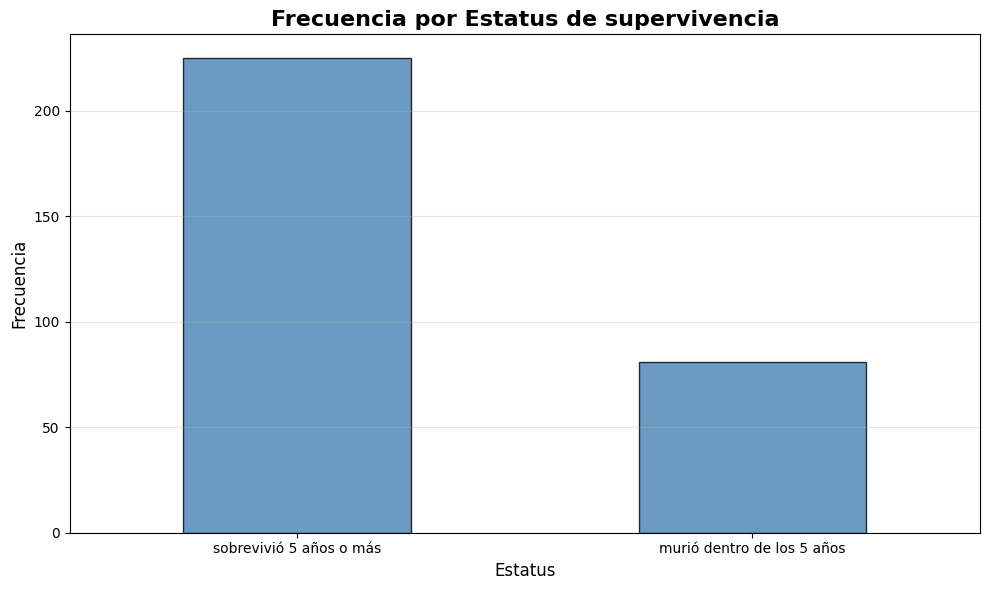

In [70]:
#Mapear status a texto
status_map = {
    1: "sobrevivió 5 años o más",
    2: "murió dentro de los 5 años"
}

df['estatus_supervivencia'] = df['estatus'].map(status_map)

# Contar frecuencia status
conteo = df['estatus_supervivencia'].value_counts().reindex(status_map.values())

# Grafico de barras
plt.figure(figsize=(10, 6))
conteo.plot(kind='bar', color='steelblue', edgecolor='black', alpha=0.8)
plt.title('Frecuencia por Estatus de supervivencia', fontsize=16, weight='bold')
plt.xlabel('Estatus', fontsize=12)
plt.ylabel('Frecuencia', fontsize=12)
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [71]:
print('Frecuencia por estatus:\n', conteo)

Frecuencia por estatus:
 estatus_supervivencia
sobrevivió 5 años o más       225
murió dentro de los 5 años     81
Name: count, dtype: int64


### Boxplots para identificar outliers en las columnas numéricas.

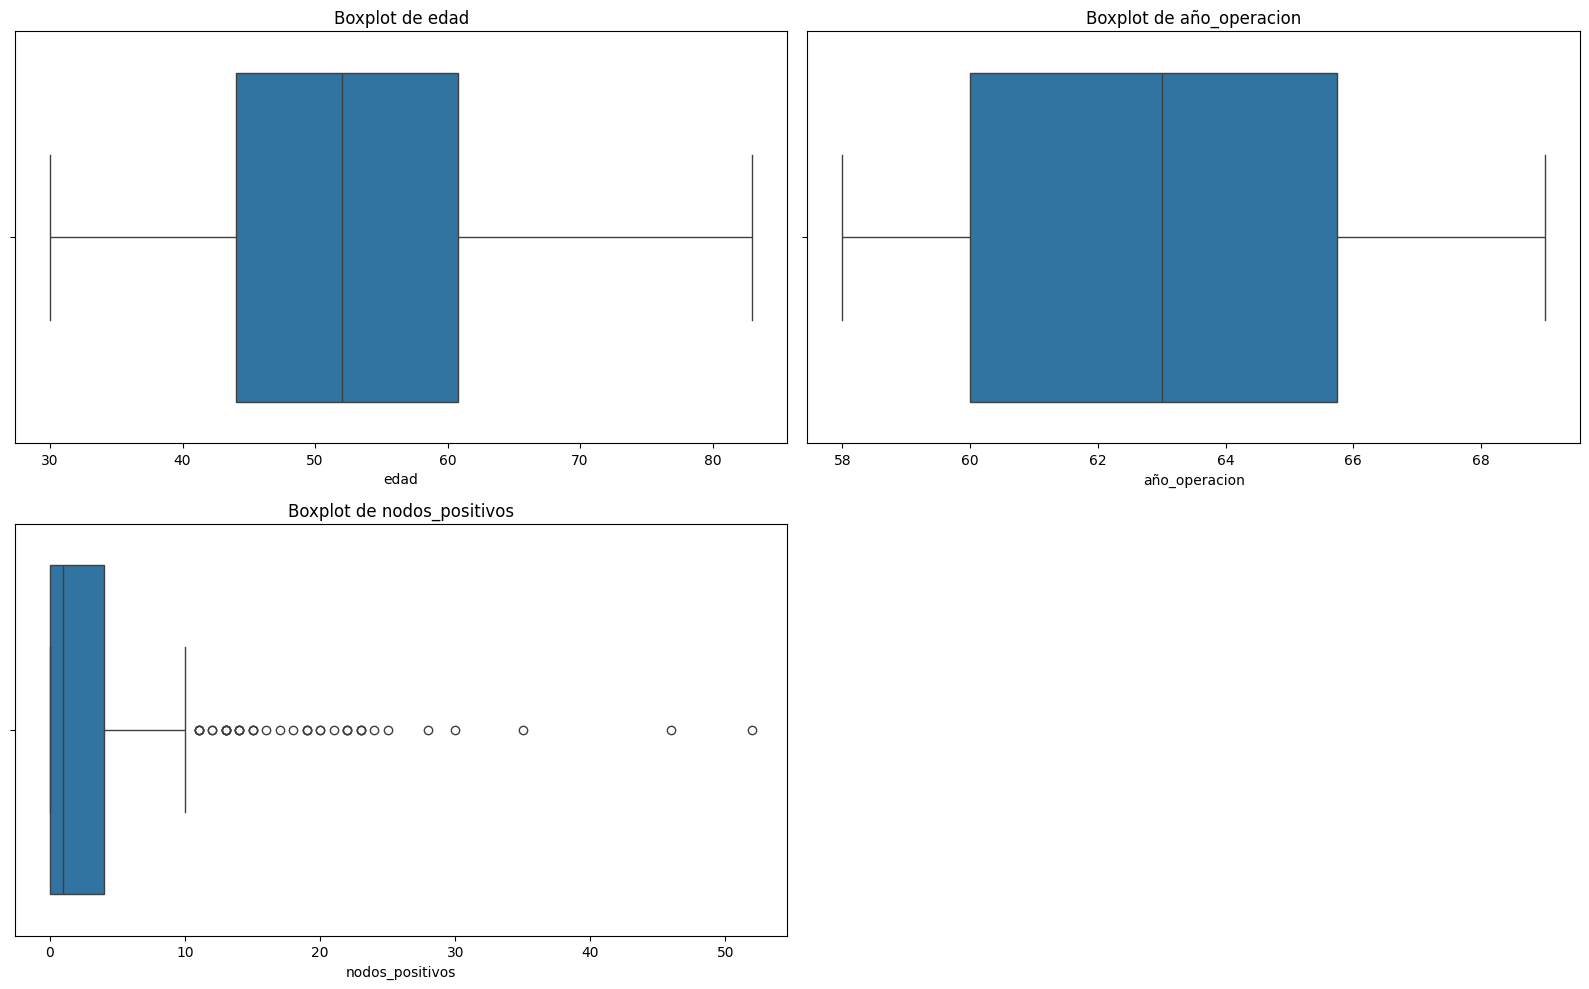

In [72]:
# Configurar el tamaño de la figura
plt.figure(figsize=(16, 10))

# Crear boxplots para cada columna numérica
for i, col in enumerate(col_numericas, 1):
    plt.subplot(2, 2, i)  # 2 filas, 2 columnas de subplots
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot de {col}')
plt.tight_layout()
plt.show()


### Matriz de correlación y mapa de calor.

Matriz de correlación:
                     edad  año_operacion  nodos_positivos
edad             1.000000       0.089529        -0.063176
año_operacion    0.089529       1.000000        -0.003764
nodos_positivos -0.063176      -0.003764         1.000000


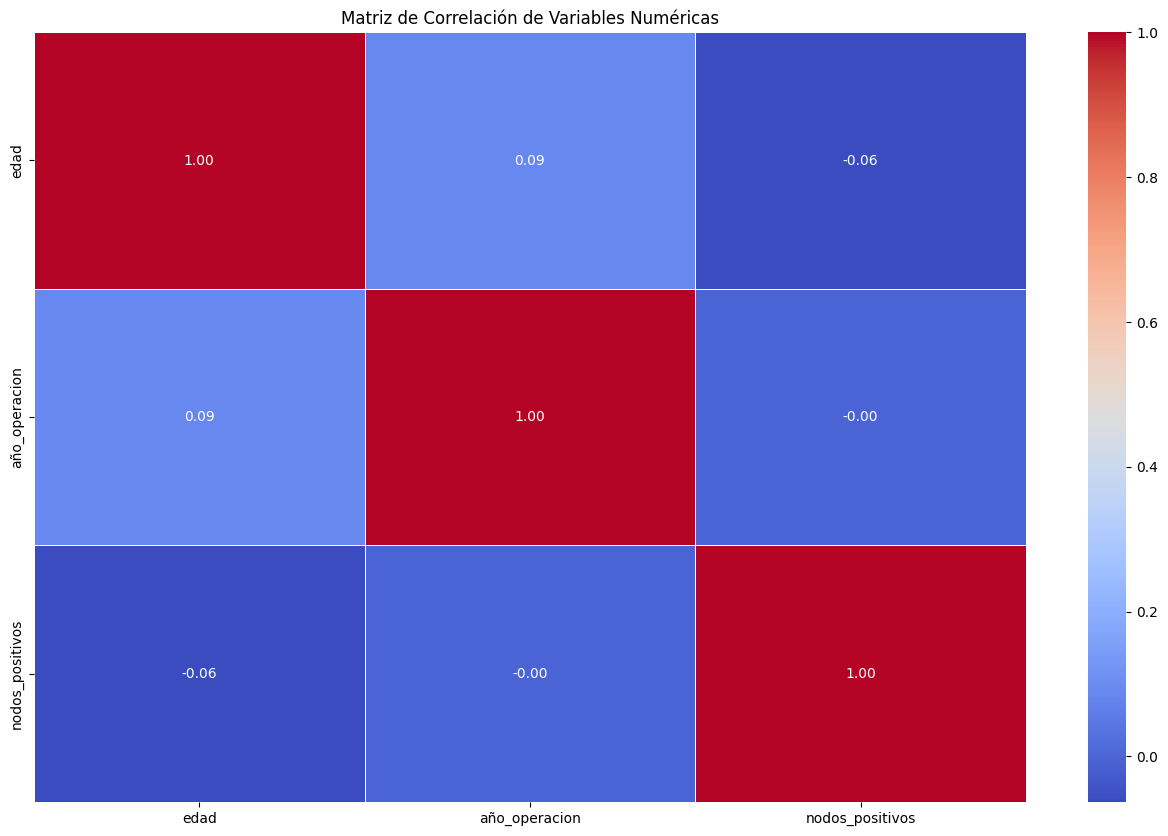

In [73]:
# Seleccionar solo las columnas numéricas
numeric_columns = df.select_dtypes(include=[np.number])

# Calcular la matriz de correlación
corr_matrix = numeric_columns.corr()

# Mostrar la matriz de correlación
print("Matriz de correlación:")
print(corr_matrix)

# Visualizar la matriz de correlación con un heatmap
plt.figure(figsize=(16, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Matriz de Correlación de Variables Numéricas')
plt.show()

### Pairplot para visualizar relaciones entre variables numéricas.

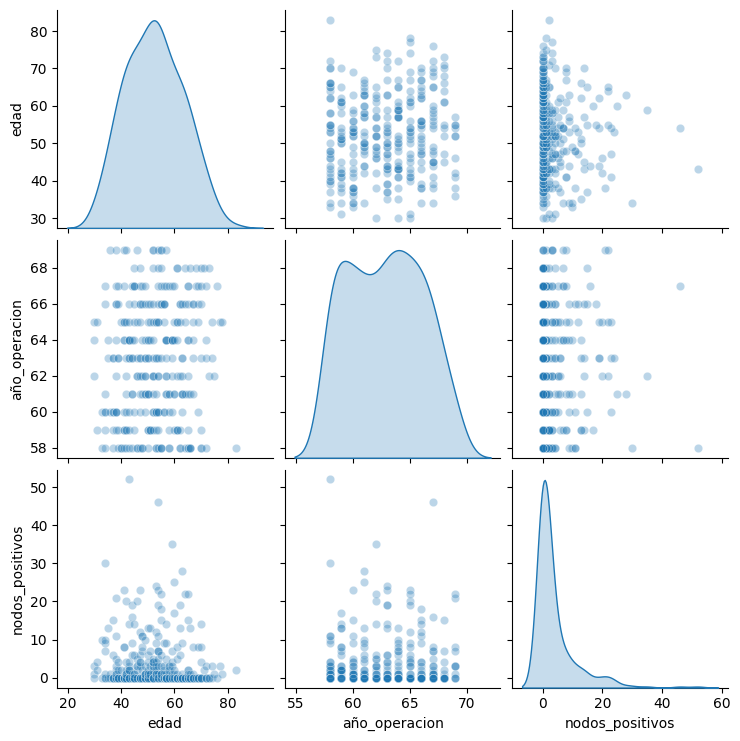

In [74]:
# Crear un scatterplot para todas las combinaciones de variables numéricas
sns.pairplot(df[col_numericas], plot_kws={'alpha': 0.3}, diag_kind='kde')

# Mostrar el gráfico
plt.show()

### Pruebas de normalidad (Shapiro-Wilk, Anderson-Darling, Kolmogorov-Smirnov) y QQplot para las columnas numéricas.

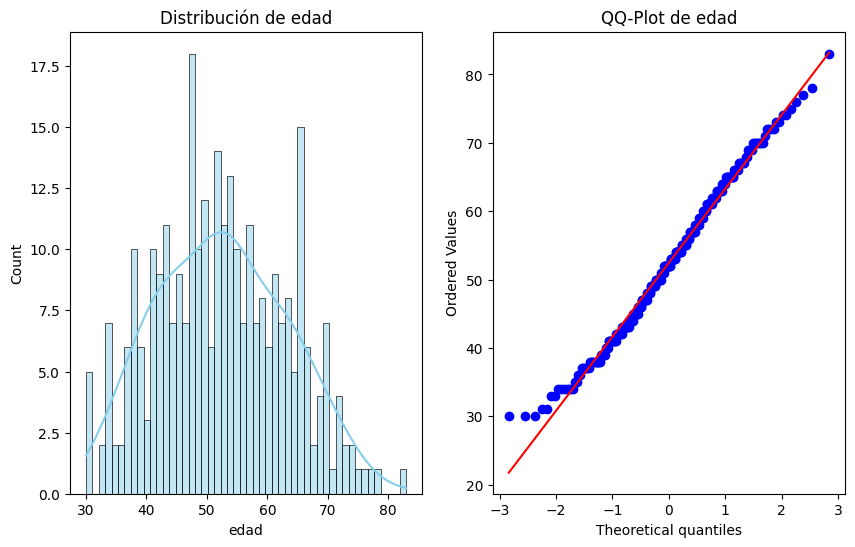


Pruebas de normalidad para la columna: edad
Shapiro-Wilk Test: p-valor = 0.02605
Kolmogorov-Smirnov Test: p-valor = 0.46980
Anderson-Darling Test: Estadístico = 0.73156
  Al nivel de significancia 15.0%, los datos NO parecen normales.

  Al nivel de significancia 10.0%, los datos NO parecen normales.

  Al nivel de significancia 5.0%, los datos parecen normales.
  Al nivel de significancia 2.5%, los datos parecen normales.
  Al nivel de significancia 1.0%, los datos parecen normales.


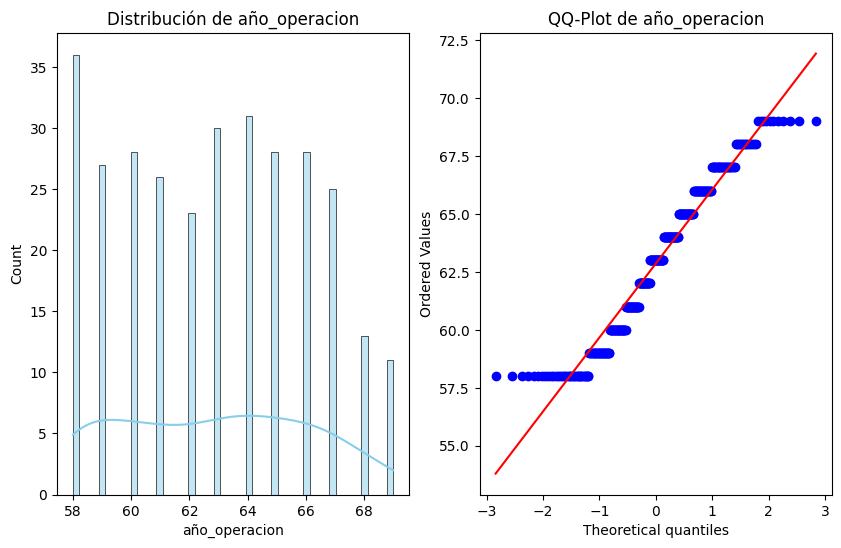


Pruebas de normalidad para la columna: año_operacion
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00158
Anderson-Darling Test: Estadístico = 4.31374
  Al nivel de significancia 15.0%, los datos NO parecen normales.

  Al nivel de significancia 10.0%, los datos NO parecen normales.

  Al nivel de significancia 5.0%, los datos NO parecen normales.

  Al nivel de significancia 2.5%, los datos NO parecen normales.

  Al nivel de significancia 1.0%, los datos NO parecen normales.



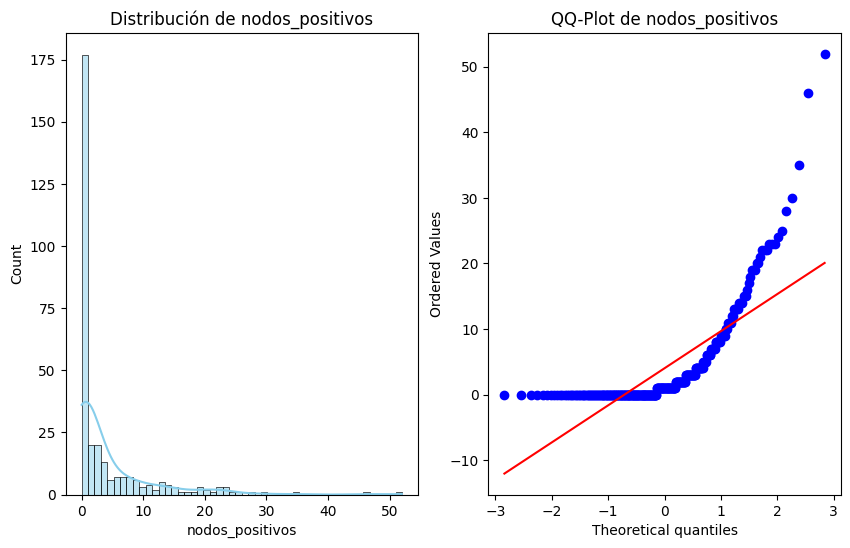


Pruebas de normalidad para la columna: nodos_positivos
Shapiro-Wilk Test: p-valor = 0.00000
Kolmogorov-Smirnov Test: p-valor = 0.00000
Anderson-Darling Test: Estadístico = 39.68662
  Al nivel de significancia 15.0%, los datos NO parecen normales.

  Al nivel de significancia 10.0%, los datos NO parecen normales.

  Al nivel de significancia 5.0%, los datos NO parecen normales.

  Al nivel de significancia 2.5%, los datos NO parecen normales.

  Al nivel de significancia 1.0%, los datos NO parecen normales.



In [75]:
#===================================
#FUNCIONES DE PRUEBAS DE NORMALIDAD#
#===================================

# Función para realizar pruebas de normalidad
def normality_tests(data, column_name):
    print(f"\nPruebas de normalidad para la columna: {column_name}")

    # Prueba de Shapiro-Wilk
    shapiro_test = stats.shapiro(data.sample(min(5000, len(data)), random_state=42))  # Muestra de 5000 para evitar problemas de cómputo
    print(f"Shapiro-Wilk Test: p-valor = {shapiro_test.pvalue:.5f}")

    # Prueba de Kolmogorov-Smirnov
    ks_test = stats.kstest(data, 'norm', args=(data.mean(), data.std()))
    print(f"Kolmogorov-Smirnov Test: p-valor = {ks_test.pvalue:.5f}")

    # Prueba de Anderson-Darling
    anderson_test = stats.anderson(data, dist='norm')
    print(f"Anderson-Darling Test: Estadístico = {anderson_test.statistic:.5f}")
    for i in range(len(anderson_test.critical_values)):
        sl, cv = anderson_test.significance_level[i], anderson_test.critical_values[i]
        if anderson_test.statistic < cv:
            print(f"  Al nivel de significancia {sl}%, los datos parecen normales.")
        else:
            print(f"  Al nivel de significancia {sl}%, los datos NO parecen normales.\n")

# Función para graficar histograma y QQ-Plot
def plot_distribution(data, column_name):
    plt.figure(figsize=(10, 6))

    # Histograma
    plt.subplot(1, 2, 1)
    sns.histplot(data, bins=50, kde=True, color="skyblue")
    plt.title(f"Distribución de {column_name}")

    # QQ-Plot
    plt.subplot(1, 2, 2)
    stats.probplot(data, dist="norm", plot=plt)
    plt.title(f"QQ-Plot de {column_name}")
    plt.show()

#===USO DE FUNCIONES DE NORMALIDAD===
for column in numeric_columns:
    data = df[column]
    plot_distribution(data, column)
    normality_tests(data, column)



## 3. Identificar y tratar los datos faltantes utilizando técnicas como imputación por media, mediana o moda, o eliminación de filas/columnas según sea apropiado.

In [89]:
# Identificar valores faltantes
for col in df.columns :
  #print(f'Valores únicos en {col}:{df[col].unique()}')
  print(f'Conteo de valores en:\n{df[col].value_counts()}')

Conteo de valores en:
edad
52    14
54    13
50    12
43    11
57    11
53    11
47    11
41    10
38    10
65    10
55    10
49    10
42     9
45     9
61     9
63     8
59     8
34     7
44     7
46     7
58     7
62     7
56     7
70     7
48     7
60     6
51     6
67     6
39     6
37     6
64     5
66     5
69     4
72     4
30     3
40     3
36     2
35     2
33     2
31     2
68     2
74     2
73     2
71     1
75     1
76     1
77     1
78     1
83     1
Name: count, dtype: int64
Conteo de valores en:
año_operacion
58    36
64    31
63    30
65    28
66    28
60    28
59    27
61    26
67    25
62    23
68    13
69    11
Name: count, dtype: int64
Conteo de valores en:
nodos_positivos
0     136
1      41
3      20
2      20
4      13
6       7
7       7
8       7
5       6
9       6
13      5
14      4
11      4
10      3
15      3
22      3
23      3
19      3
12      2
20      2
30      1
21      1
52      1
16      1
24      1
46      1
18      1
35      1
17      1
25      

In [90]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 306 entries, 0 to 305
Data columns (total 5 columns):
 #   Column                 Non-Null Count  Dtype   
---  ------                 --------------  -----   
 0   edad                   306 non-null    int64   
 1   año_operacion          306 non-null    int64   
 2   nodos_positivos        306 non-null    int64   
 3   estatus                306 non-null    category
 4   estatus_supervivencia  306 non-null    category
dtypes: category(2), int64(3)
memory usage: 8.1 KB


# EDA después del tratamiento de datos faltantes y comparar los resultados.

* No aplica

En este caso no tenemos datos perdidos o valores faltantes, lo anterior se confirma con los datos mostrados en `df.info()` y `conteo de value_counts`

Así mismo, se verifico en la información de la fuente de datos: https://archive.ics.uci.edu/dataset/43/haberman+s+survival